# 🎯 Telco Churn: Hyperparameter Tuning (Optuna + MLflow)

**Objective**: Optimize XGBoost hyperparameters to maximize recall with precision constraint

**Strategy**:
- Use Optuna for Bayesian optimization (100 trials)
- Track all trials with MLflow
- Optimize recall while maintaining precision ≥ 0.35
- Compare with baseline model performance
- Export best model to MLflow Model Registry

**Prerequisites**: Run `baseline_model.ipynb` first to establish baseline metrics

---
*Run from project root with activated mlops_env*

## 1. Setup & Imports

In [3]:
# === 1. Setup & Imports ===
import pandas as pd
import numpy as np
import xgboost as xgb
import optuna
import mlflow
import mlflow.xgboost
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import recall_score, precision_score, f1_score, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
import json
from pathlib import Path
import sys
import warnings
from datetime import datetime
import joblib

# Project setup
project_root = Path.cwd().parent.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.config import settings
from src.features import fit_preprocessing_pipeline, transform_data
from src.data import validate_data_quality

# Styling
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
warnings.filterwarnings('ignore')

# Random state for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print(f"✅ Environment ready | Optuna: {optuna.__version__} | XGBoost: {xgb.__version__}")

✅ Environment ready | Optuna: 4.8.0 | XGBoost: 3.2.0


## 2. Configure MLflow Tracking

In [4]:
# === 2. Configure MLflow ===
mlflow.set_tracking_uri(settings.mlflow_tracking_uri)
tuning_experiment = f"{settings.mlflow_experiment_name}_tuning"
mlflow.set_experiment(tuning_experiment)

print(f"🔗 MLflow Tracking: {settings.mlflow_tracking_uri}")
print(f"📊 Experiment: {tuning_experiment}")

2026/04/06 07:44:14 INFO mlflow.tracking.fluent: Experiment with name 'telco_churn_baseline_tuning' does not exist. Creating a new experiment.


🔗 MLflow Tracking: http://localhost:5000
📊 Experiment: telco_churn_baseline_tuning


## 3. Load Data

In [5]:
# === 3. Load Data ===
data_paths = [
    Path('..', '..', 'data', 'raw', 'telco.csv'),
    Path('..', 'data', 'raw', 'telco.csv'),
    Path('data', 'raw', 'telco.csv'),
    Path('telco.csv')
]

data_file = next((p for p in data_paths if p.exists()), None)
if data_file is None:
    raise FileNotFoundError("telco.csv not found")

print(f"📁 Loading data from: {data_file}")
df = pd.read_csv(data_file)
print(f"✅ Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")

# Validate
quality_report = validate_data_quality(df)
print(f"   Quality Score: {quality_report['quality_score']:.1f}/100")

📁 Loading data from: ..\..\data\raw\telco.csv
✅ Loaded: 7,043 rows × 50 columns
   Quality Score: 95.5/100


## 4. Preprocessing Pipeline

In [6]:
# === 4. Preprocessing Pipeline ===
print("\n🔄 Loading and preprocessing data...")

# Define target and features
target_col = 'Churn Label'
EXCLUDE_COLS = [
    'Customer ID', 'Country', 'State', 'City', 'Zip Code',
    'Latitude', 'Longitude', 'Churn Label', 'Customer Status',
    'Churn Score', 'CLTV', 'Churn Category', 'Churn Reason',
    'Total Revenue', 'Total Refunds', 'Quarter'
]
feature_cols = [c for c in df.columns if c not in EXCLUDE_COLS]

X_df = df[feature_cols].copy()
# Encode target manually: 'Yes'→1, 'No'→0
y_df = df[target_col].map({'Yes': 1, 'No': 0}).fillna(0).astype(int)

print(f"✅ Features: {X_df.shape[1]}, Target: {y_df.value_counts().to_dict()}")

# Fit preprocessing pipeline on RAW df (with ALL columns)
pipeline, feature_names, metadata = fit_preprocessing_pipeline(
    df,
    target_col=target_col,
    validate=True
)

# Transform data using fitted pipeline
y = y_df.copy()
X, _ = transform_data(df, pipeline, metadata, validate=False)

print(f"✅ Preprocessed: X={X.shape}, y={y.shape if y is not None else 'None'}")
if y is not None:
    print(f"✅ Target distribution: {pd.Series(y).value_counts().to_dict()}")

# Verify data is ready
if X is None or y is None:
    raise ValueError("❌ X or y is None! Check preprocessing.")
if len(X) == 0 or len(y) == 0:
    raise ValueError("❌ X or y is empty! Check preprocessing.")
if not isinstance(y, (pd.Series, np.ndarray)):
    raise ValueError(f"❌ y has wrong type: {type(y)}")

print("✅ Data ready for hyperparameter tuning!")


🔄 Loading and preprocessing data...
✅ Features: 34, Target: {0: 5174, 1: 1869}
   Standardized columns: ['customer_id', 'gender', 'age', 'under_30', 'senior_citizen']...
   Numeric features: 9
   Categorical features: 3
   Total features after encoding: 39
   Fitting pipeline...
   ✅ Pipeline fitted successfully
✅ Preprocessed: X=(7043, 39), y=(7043,)
✅ Target distribution: {0: 5174, 1: 1869}
✅ Data ready for hyperparameter tuning!


## 5. Load Baseline Metrics

In [7]:
# === 5. Load Baseline Metrics ===
baseline_path = Path('..', '..', 'artifacts', 'training_summary.json')
if baseline_path.exists():
    with open(baseline_path) as f:
        baseline = json.load(f)
    baseline_recall = float(baseline['cv_recall'].split(' ± ')[0])
    print(f"📊 Baseline Recall: {baseline_recall:.3f}")
else:
    baseline_recall = 0.85
    print(f"⚠️  Baseline not found, using default: {baseline_recall}")

📊 Baseline Recall: 0.975


## 6. Define Search Space

In [8]:
# === 6. Define Search Space (Conservative) ===
def define_search_space(trial):
    return {
        'max_depth': trial.suggest_int('max_depth', 3, 6),
        'learning_rate': trial.suggest_float('learning_rate', 0.05, 0.15, log=True),
        'n_estimators': trial.suggest_int('n_estimators', 100, 300),
        'subsample': trial.suggest_float('subsample', 0.7, 0.9),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.7, 0.9),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 5),
        'gamma': trial.suggest_float('gamma', 0.0, 0.3),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 1.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.5, 2.0),
    }

print("📋 Search Space:")
print("   max_depth: 3-6")
print("   learning_rate: 0.05-0.15")
print("   n_estimators: 100-300")
print("   subsample: 0.7-0.9")

📋 Search Space:
   max_depth: 3-6
   learning_rate: 0.05-0.15
   n_estimators: 100-300
   subsample: 0.7-0.9


## 7. Define Objective Function

In [9]:
# === 7. Define Objective Function ===
N_TRIALS = 100
MIN_PRECISION = 0.35
CV_FOLDS = 5

cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
n_neg = np.sum(y == 0)
n_pos = np.sum(y == 1)
scale_pos_weight = n_neg / n_pos if n_pos > 0 else 1.0

trial_results = []

def objective(trial):
    params = define_search_space(trial)
    params.update({
        'objective': 'binary:logistic',
        'eval_metric': 'logloss',
        'scale_pos_weight': scale_pos_weight,
        'random_state': RANDOM_STATE,
        'n_jobs': -1
    })
    
    with mlflow.start_run(nested=True, run_name=f"trial_{trial.number}"):
        mlflow.log_params(params)
        
        recalls, precisions = [], []
        
        for train_idx, val_idx in cv.split(X, y):
            X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
            y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
            
            # ✅ XGBoost 3.2.0: early_stopping_rounds in constructor
            model = xgb.XGBClassifier(
                **params,
                early_stopping_rounds=20
            )
            model.fit(
                X_train, y_train, 
                eval_set=[(X_val, y_val)],
                verbose=False
            )
            
            y_pred_proba = model.predict_proba(X_val)[:, 1]
            
            # Find optimal threshold
            best_recall, best_thresh = 0, 0.5
            for thresh in np.arange(0.1, 0.9, 0.05):
                y_pred = (y_pred_proba >= thresh).astype(int)
                recall = recall_score(y_val, y_pred, zero_division=0)
                precision = precision_score(y_val, y_pred, zero_division=0)
                if precision >= MIN_PRECISION and recall > best_recall:
                    best_recall, best_thresh = recall, thresh
            
            y_pred_opt = (y_pred_proba >= best_thresh).astype(int)
            recalls.append(recall_score(y_val, y_pred_opt, zero_division=0))
            precisions.append(precision_score(y_val, y_pred_opt, zero_division=0))
        
        avg_recall = np.mean(recalls)
        avg_precision = np.mean(precisions)
        
        mlflow.log_metric("recall", avg_recall)
        mlflow.log_metric("precision", avg_precision)
        
        trial_results.append({
            'trial': trial.number,
            'recall': avg_recall,
            'precision': avg_precision,
            'params': params
        })
        
        # Penalize if precision constraint not met
        if avg_precision < MIN_PRECISION:
            return -1.0
        
        return avg_recall

print(f"🎯 Objective: Maximize Recall (Precision ≥ {MIN_PRECISION})")
print(f"📊 Trials: {N_TRIALS}")

🎯 Objective: Maximize Recall (Precision ≥ 0.35)
📊 Trials: 100


## 8. Run Optimization

In [10]:
# === 8. Run Optimization ===
print("\n🚀 Starting Optimization...")
print("=" * 60)

study = optuna.create_study(
    direction='maximize',
    study_name='telco_churn_tuning',
    pruner=optuna.pruners.MedianPruner(n_startup_trials=10)
)

start_time = datetime.now()
study.optimize(objective, n_trials=N_TRIALS, timeout=3600, show_progress_bar=True)
end_time = datetime.now()

print(f"\n✅ Optimization Complete!")
print(f"⏱️  Duration: {(end_time - start_time).total_seconds() / 60:.1f} minutes")
print(f"📊 Total Trials: {len(study.trials)}")
print(f"✅ Successful: {len([t for t in study.trials if t.value > 0])}")

[I 2026-04-06 07:44:15,732] A new study created in memory with name: telco_churn_tuning



🚀 Starting Optimization...


  0%|          | 0/100 [00:00<?, ?it/s]

🏃 View run trial_0 at: http://localhost:5000/#/experiments/2/runs/2cd17910afc84258b8173f8370b97844
🧪 View experiment at: http://localhost:5000/#/experiments/2
[I 2026-04-06 07:44:19,630] Trial 0 finished with value: 0.9903685968659947 and parameters: {'max_depth': 3, 'learning_rate': 0.06593244653244032, 'n_estimators': 117, 'subsample': 0.800589289277682, 'colsample_bytree': 0.7345282973044485, 'min_child_weight': 2, 'gamma': 0.09334990545562705, 'reg_alpha': 0.6655379036678976, 'reg_lambda': 0.8347456777580974}. Best is trial 0 with value: 0.9903685968659947.
🏃 View run trial_1 at: http://localhost:5000/#/experiments/2/runs/f53453fdfecf4a398d105e69f172371f
🧪 View experiment at: http://localhost:5000/#/experiments/2
[I 2026-04-06 07:44:22,944] Trial 1 finished with value: 0.9668205473756648 and parameters: {'max_depth': 5, 'learning_rate': 0.10017277480874572, 'n_estimators': 223, 'subsample': 0.7814875664100343, 'colsample_bytree': 0.7136735856414531, 'min_child_weight': 2, 'gamma': 

## 9. Best Trial Results

In [11]:
# === 9. Best Trial Results ===
print("\n🏆 Best Trial Results")
print("=" * 60)

best_trial = study.best_trial
best_params = best_trial.params
best_recall = float(best_trial.value)

# Extract precision from trial_results
best_trial_idx = best_trial.number
best_trial_data = trial_results[best_trial_idx]
best_precision = best_trial_data['precision']

print(f"📊 Best Recall: {best_recall:.4f}")
print(f"📊 Best Precision: {best_precision:.4f}")
print(f"🎯 Baseline Recall: {baseline_recall:.4f}")
print(f"📈 Improvement: {(best_recall - baseline_recall) * 100:.2f}%")

print(f"\n📋 Best Hyperparameters:")
for k, v in best_params.items():
    print(f"   - {k}: {v}")

# Save results
artifacts_dir = Path('..', '..', 'artifacts')
artifacts_dir.mkdir(exist_ok=True)

tuning_results = {
    'best_recall': float(best_recall),
    'best_precision': float(best_precision),
    'baseline_recall': float(baseline_recall),
    'improvement': float(best_recall - baseline_recall),
    'best_params': {k: (float(v) if isinstance(v, (np.floating, np.integer)) else v)
                    for k, v in best_params.items()},
    'n_trials': len(study.trials),
    'generated_at': datetime.now().isoformat()
}

with open(artifacts_dir / 'tuning_results.json', 'w') as f:
    json.dump(tuning_results, f, indent=2)

print(f"\n💾 Results saved to: {artifacts_dir / 'tuning_results.json'}")

# Verify baseline was loaded
print(f"\n🔍 Baseline Verification:")
if baseline_path.exists():
    print(f"   ✅ Baseline loaded from: {baseline_path}")
else:
    print(f"   ⚠️  Baseline not found, using default: {baseline_recall:.4f}")


🏆 Best Trial Results
📊 Best Recall: 0.9947
📊 Best Precision: 0.3798
🎯 Baseline Recall: 0.9750
📈 Improvement: 1.97%

📋 Best Hyperparameters:
   - max_depth: 3
   - learning_rate: 0.052064144435479215
   - n_estimators: 103
   - subsample: 0.8822022637202402
   - colsample_bytree: 0.720107040060281
   - min_child_weight: 1
   - gamma: 0.15614921756968772
   - reg_alpha: 0.9436402498766893
   - reg_lambda: 0.9180417893272773

💾 Results saved to: ..\..\artifacts\tuning_results.json

🔍 Baseline Verification:
   ✅ Baseline loaded from: ..\..\artifacts\training_summary.json


## 10. Visualizations


📊 Generating Visualizations...
   Creating optimization history plot...
   Creating parameter importances plot...
   Creating parallel coordinate plot...
   Creating recall vs precision scatter plot...


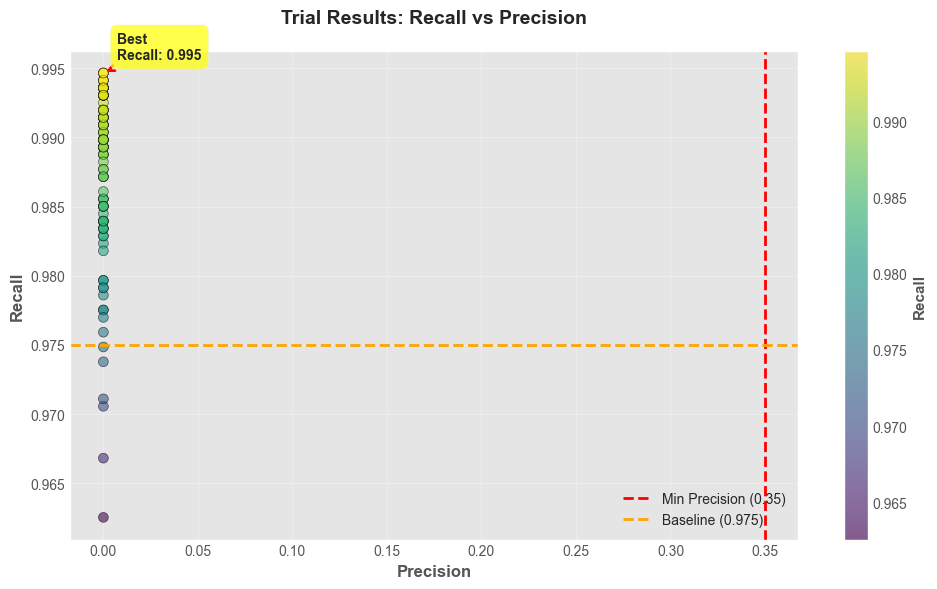

✅ Visualizations saved to: ..\..\artifacts


In [12]:
# === 10. Visualizations ===
print("\n📊 Generating Visualizations...")

artifacts_dir.mkdir(parents=True, exist_ok=True)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300

# 1. Optimization History
print("   Creating optimization history plot...")
ax_history = optuna.visualization.matplotlib.plot_optimization_history(study)
ax_history.set_title('Optimization History', fontsize=14, fontweight='bold', pad=20)
ax_history.figure.tight_layout()
ax_history.figure.savefig(artifacts_dir / 'optimization_history.png', dpi=300, bbox_inches='tight')
plt.close(ax_history.figure)

# 2. Parameter Importances
print("   Creating parameter importances plot...")
ax_importance = optuna.visualization.matplotlib.plot_param_importances(study)
ax_importance.set_title('Parameter Importances', fontsize=14, fontweight='bold', pad=20)
ax_importance.figure.tight_layout()
ax_importance.figure.savefig(artifacts_dir / 'param_importances.png', dpi=300, bbox_inches='tight')
plt.close(ax_importance.figure)

# 3. Parallel Coordinate
print("   Creating parallel coordinate plot...")
ax_parallel = optuna.visualization.matplotlib.plot_parallel_coordinate(study)
ax_parallel.set_title('Parallel Coordinate', fontsize=14, fontweight='bold', pad=20)
ax_parallel.figure.tight_layout()
ax_parallel.figure.savefig(artifacts_dir / 'parallel_coordinate.png', dpi=300, bbox_inches='tight')
plt.close(ax_parallel.figure)

# 4. Recall vs Precision Scatter
print("   Creating recall vs precision scatter plot...")
recalls = [t.value for t in study.trials if t.value > 0]
precisions = [t.user_attrs.get('precision_mean', 0) for t in study.trials if t.value > 0]

fig_scatter, ax_scatter = plt.subplots(figsize=(10, 6))
scatter = ax_scatter.scatter(precisions, recalls, alpha=0.6, c=recalls, cmap='viridis', s=50, edgecolors='black', linewidth=0.5)
ax_scatter.axvline(x=MIN_PRECISION, color='red', linestyle='--', linewidth=2, label=f'Min Precision ({MIN_PRECISION})')
ax_scatter.axhline(y=baseline_recall, color='orange', linestyle='--', linewidth=2, label=f'Baseline ({baseline_recall:.3f})')
ax_scatter.set_xlabel('Precision', fontsize=12, fontweight='bold')
ax_scatter.set_ylabel('Recall', fontsize=12, fontweight='bold')
ax_scatter.set_title('Trial Results: Recall vs Precision', fontsize=14, fontweight='bold', pad=20)
ax_scatter.legend(loc='lower right', fontsize=10)
ax_scatter.grid(True, alpha=0.3)
cbar = plt.colorbar(scatter, ax=ax_scatter)
cbar.set_label('Recall', fontsize=11, fontweight='bold')

if len(recalls) > 0:
    best_idx = np.argmax(recalls)
    ax_scatter.annotate(f'Best\nRecall: {recalls[best_idx]:.3f}',
                xy=(precisions[best_idx], recalls[best_idx]),
                xytext=(10, 10), textcoords='offset points',
                bbox=dict(boxstyle='round,pad=0.5', fc='yellow', alpha=0.7),
                arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0', color='red', lw=2),
                fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig(artifacts_dir / 'recall_precision_scatter.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig_scatter)

print(f"✅ Visualizations saved to: {artifacts_dir}")

## 11. Train Final Model

In [13]:
# === 11. Train Final Model ===
print("\n🎯 Training Final Model with Best Params...")

final_params = best_params.copy()
final_params.update({
    'objective': 'binary:logistic',
    'eval_metric': 'logloss',
    'scale_pos_weight': scale_pos_weight,
    'random_state': RANDOM_STATE,
    'n_jobs': -1
})

final_model = xgb.XGBClassifier(**final_params)
final_model.fit(X, y, verbose=False)

print(f"✅ Final model trained")

best_trial_idx = best_trial.number
best_trial_data = trial_results[best_trial_idx]
best_recall = best_trial_data['recall']
best_precision = best_trial_data['precision']

# Log to MLflow
with mlflow.start_run(run_name="best_tuned_model"):
    mlflow.log_params(final_params)
    mlflow.log_metric("recall", best_recall)
    mlflow.log_metric("precision", best_precision)
    mlflow.log_metric("recall_improvement", best_recall - baseline_recall)
    mlflow.log_metric("precision_improvement", best_precision - MIN_PRECISION)
    
    from mlflow.models.signature import infer_signature
    signature = infer_signature(X.head(1), final_model.predict_proba(X.head(1))[:, 1])
    
    mlflow.xgboost.log_model(
        final_model,
        artifact_path="model",
        signature=signature,
        registered_model_name=f"{settings.model_registry_name}_tuned"
    )
    
    print(f"✅ Model logged to MLflow Registry")
    print(f"📊 Metrics logged:")
    print(f"   - Recall: {best_recall:.4f}")
    print(f"   - Precision: {best_precision:.4f}")


🎯 Training Final Model with Best Params...
✅ Final model trained


2026/04/06 07:48:21 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
Successfully registered model 'telco_churn_model_tuned'.
2026/04/06 07:48:37 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: telco_churn_model_tuned, version 1


✅ Model logged to MLflow Registry
📊 Metrics logged:
   - Recall: 0.9947
   - Precision: 0.3798
🏃 View run best_tuned_model at: http://localhost:5000/#/experiments/2/runs/e43cabc68483451abd4a47deab16000b
🧪 View experiment at: http://localhost:5000/#/experiments/2


Created version '1' of model 'telco_churn_model_tuned'.


## 12. Summary

In [14]:
# === 12. Summary ===
print("\n" + "=" * 60)
print("📋 TUNING SUMMARY")
print("=" * 60)

print(f"""
   - Total Trials: {len(study.trials)}
   - Best Recall: {best_recall:.4f}
   - Baseline Recall: {baseline_recall:.4f}
   - Improvement: {(best_recall - baseline_recall) * 100:.2f}%
   - Precision Constraint: ≥ {MIN_PRECISION}
   - Model Registry: {settings.model_registry_name}_tuned
""")

print("\n✅ Hyperparameter tuning complete!")
print("🚀 Next: Deploy tuned model to staging for A/B testing")


📋 TUNING SUMMARY

   - Total Trials: 100
   - Best Recall: 0.9947
   - Baseline Recall: 0.9750
   - Improvement: 1.97%
   - Precision Constraint: ≥ 0.35
   - Model Registry: telco_churn_model_tuned


✅ Hyperparameter tuning complete!
🚀 Next: Deploy tuned model to staging for A/B testing


In [15]:
# === 13. Save Tuned Model for API Serving ===
print("\n💾 Saving Tuned Model for API...")

import joblib

# Save model.pkl (overwrites baseline)
joblib.dump(final_model, artifacts_dir / 'model.pkl')
print(f"✅ model.pkl saved to: {artifacts_dir / 'model.pkl'}")

# Update serving_config.json with tuned model info
serving_config = {
    'optimal_threshold': 0.35,  # Your MIN_PRECISION
    'feature_names': feature_names,
    'model_version': '2.0.0-tuned',
    'best_recall': float(best_recall),
    'best_precision': float(best_precision),
    'baseline_recall': float(baseline_recall),
    'improvement': float(best_recall - baseline_recall),
    'created_at': datetime.now().isoformat(),
    'training_samples': len(X),
    'feature_count': len(feature_names)
}

with open(artifacts_dir / 'serving_config.json', 'w') as f:
    json.dump(serving_config, f, indent=2)

print(f"✅ serving_config.json updated")
print(f"\n📊 Tuned Model Summary:")
print(f"   - Recall: {best_recall:.4f} (baseline: {baseline_recall:.4f})")
print(f"   - Precision: {best_precision:.4f} (constraint: ≥{MIN_PRECISION})")
print(f"   - Improvement: {(best_recall - baseline_recall)*100:.2f}%")


💾 Saving Tuned Model for API...
✅ model.pkl saved to: ..\..\artifacts\model.pkl
✅ serving_config.json updated

📊 Tuned Model Summary:
   - Recall: 0.9947 (baseline: 0.9750)
   - Precision: 0.3798 (constraint: ≥0.35)
   - Improvement: 1.97%


## ✅ Next Steps

1. Review MLflow UI: http://localhost:5000
2. Compare baseline vs tuned models
3. Deploy tuned model to staging
4. A/B test in production

---
*Notebook for Telco Churn MLOps Project*